## Price-Volume Trade-offs at Tesla: A Data-Driven Analysis of Margin Compression and Financial Stability

### Research Goal: This analysis evaluates how Tesla's aggressive pricing strategy interacts with production scaling to influence its financial durability.


# PART 1 Setup

In [23]:
import sqlite3, re, requests, warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.formula.api as sm
import requests

import nltk
# Text Analysis Libraries
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.feature_extraction.text import TfidfVectorizer

from nltk.tokenize import sent_tokenize

In [17]:
# Plot Settings
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'axes.titleweight': 'bold'})

# Load Data (Ensure your CSV is updated with Total_Production and Free_Cash_Flow_mm)
CSV_URL = "https://raw.githubusercontent.com/zhukehong21-svg/tesla_analysis/main/tesla_data_new.csv"
tsla_fin = pd.read_csv(CSV_URL)

text_url = "https://raw.githubusercontent.com/zhukehong21-svg/tesla_analysis/main/MDA_Item7_Combined.txt"
response = requests.get(text_url)

df_text = pd.DataFrame({'text': [response.text]})

con = sqlite3.connect(':memory:')
df_text.to_sql("tsla_mda_text", con, index=False, if_exists="replace")
# Create an in-memory SQLite database

tsla_fin.to_sql("tsla_financial", con, index=False, if_exists="replace")

print("SQLite tables loaded successfully.")

SQLite tables loaded successfully.


# PART 2 Base Database

In [3]:
sql_query = """
    SELECT 
        Quarter,
        Total_Deliveries,
        Auto_ARPU,
        Auto_COGS_per_veh,
        Auto_Gross_Margin_pct,
        Operating_Margin_pct,
        -- Calculate Quarter-over-Quarter (QoQ) Growth using SQLite Window Functions
        ROUND((Total_Deliveries - LAG(Total_Deliveries) OVER (ORDER BY Quarter)) * 100.0 / LAG(Total_Deliveries) OVER (ORDER BY Quarter), 2) AS Deliveries_Growth_pct,
        ROUND((Auto_ARPU - LAG(Auto_ARPU) OVER (ORDER BY Quarter)) * 100.0 / LAG(Auto_ARPU) OVER (ORDER BY Quarter), 2) AS ARPU_Growth_pct,
        ROUND((Auto_COGS_per_veh - LAG(Auto_COGS_per_veh) OVER (ORDER BY Quarter)) * 100.0 / LAG(Auto_COGS_per_veh) OVER (ORDER BY Quarter), 2) AS COGS_Growth_pct
    FROM 
        tsla_financial
    ORDER BY 
        Quarter ASC;
"""
# Execute the SQL query and load the result into a new DataFrame
df_sql = pd.read_sql_query(sql_query, con)
display(df_sql.head(10))

,Quarter,Total_Deliveries,Auto_ARPU,Auto_COGS_per_veh,Auto_Gross_Margin_pct,Operating_Margin_pct,Deliveries_Growth_pct,ARPU_Growth_pct,COGS_Growth_pct
0,2022Q1,310048,54381,36491,32.9,19.2,NaN,NaN,NaN
1,2022Q2,254695,57331,41336,27.9,14.6,-17.85,5.42,13.28
2,2022Q3,343830,54364,39196,27.9,17.2,35.00,-5.18,-5.18
3,2022Q4,405278,52574,38957,25.9,16.0,17.87,-3.29,-0.61
4,2023Q1,422875,47208,37247,21.1,11.4,4.34,-10.21,-4.39
5,2023Q2,466140,45626,36866,19.2,9.6,10.23,-3.35,-1.02
6,2023Q3,435059,45109,36673,18.7,7.6,-6.67,-1.13,-0.52
7,2023Q4,484507,44505,36361,18.3,8.2,11.37,-1.34,-0.85
8,2024Q1,386810,44926,37963,15.5,5.5,-20.16,0.95,4.41
9,2024Q2,443956,44775,38551,13.9,6.3,14.77,-0.34,1.55


# Part 3 Pricing Pressure and Unit Cost Dynamics

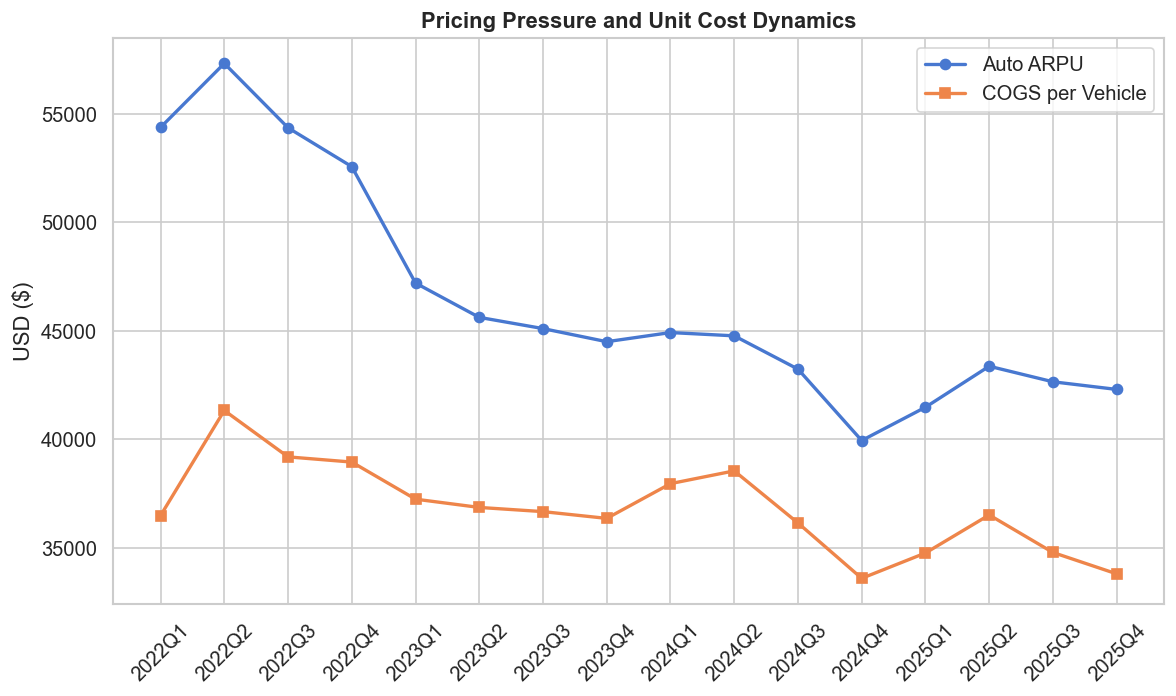

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(df_sql['Quarter'], df_sql['Auto_ARPU'],
        marker='o', linewidth=2, label='Auto ARPU')
ax.plot(df_sql['Quarter'], df_sql['Auto_COGS_per_veh'],
        marker='s', linewidth=2, label='COGS per Vehicle')

ax.set_title('Pricing Pressure and Unit Cost Dynamics')
ax.set_ylabel('USD ($)')
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

### Interpretation: 
A steady decline in Average Revenue Per Unit (ARPU) shows aggressive price cuts to stimulate demand. Because per-vehicle production costs (COGS) did not decline at the same pace until 24Q4, the profit spread per vehicle was severely compressed.

# Part 4 Correlation Analysis

## 4.1 Regression Analysis

=== Core Regression: Financial Durability vs. Production Scale ===
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           17.1919      7.391      2.326      0.037       1.224      33.160
Total_Deliveries -2.032e-05   1.76e-05     -1.157      0.268   -5.83e-05    1.76e-05
R-squared: 0.0934


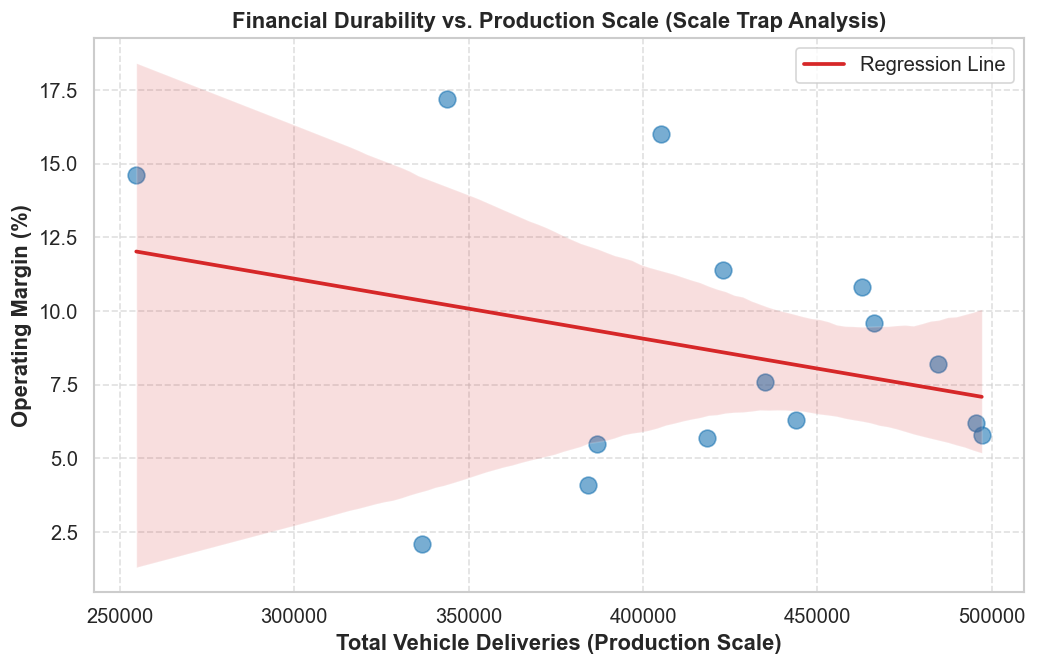

In [5]:
# 1. Prepare clean data
df_clean = df_sql.dropna().copy()
if df_clean['Operating_Margin_pct'].max() < 1:
    df_clean['Operating_Margin_pct'] = df_clean['Operating_Margin_pct'] * 100

# 2. Core Regression: Does Scaling Production Improve Durability?
# We are currently testing whether sales volume (scale) can lead to an increase in profit margins.
model_core = sm.ols('Operating_Margin_pct ~ Total_Deliveries', data=df_clean).fit()

print("=== Core Regression: Financial Durability vs. Production Scale ===")
print(model_core.summary().tables[1])
print(f"R-squared: {model_core.rsquared:.4f}")

# 3. Academic Visualization (Updated for Scale Analysis)
fig, ax = plt.subplots(figsize=(10, 6))

sns.regplot(x='Total_Deliveries', y='Operating_Margin_pct', data=df_clean, 
            scatter_kws={'s': 100, 'alpha': 0.6, 'color': '#1f77b4'}, 
            line_kws={'color': '#d62728', 'label': 'Regression Line'})

ax.set_title('Financial Durability vs. Production Scale (Scale Trap Analysis)', fontweight='bold')
ax.set_xlabel('Total Vehicle Deliveries (Production Scale)', fontweight='bold')
ax.set_ylabel('Operating Margin (%)', fontweight='bold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

=== Core Regression: Financial Durability vs. Pricing Strategy ===
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -27.0785      5.733     -4.723      0.000     -39.463     -14.694
Auto_ARPU      0.0008      0.000      6.282      0.000       0.001       0.001

R-squared: 0.7522



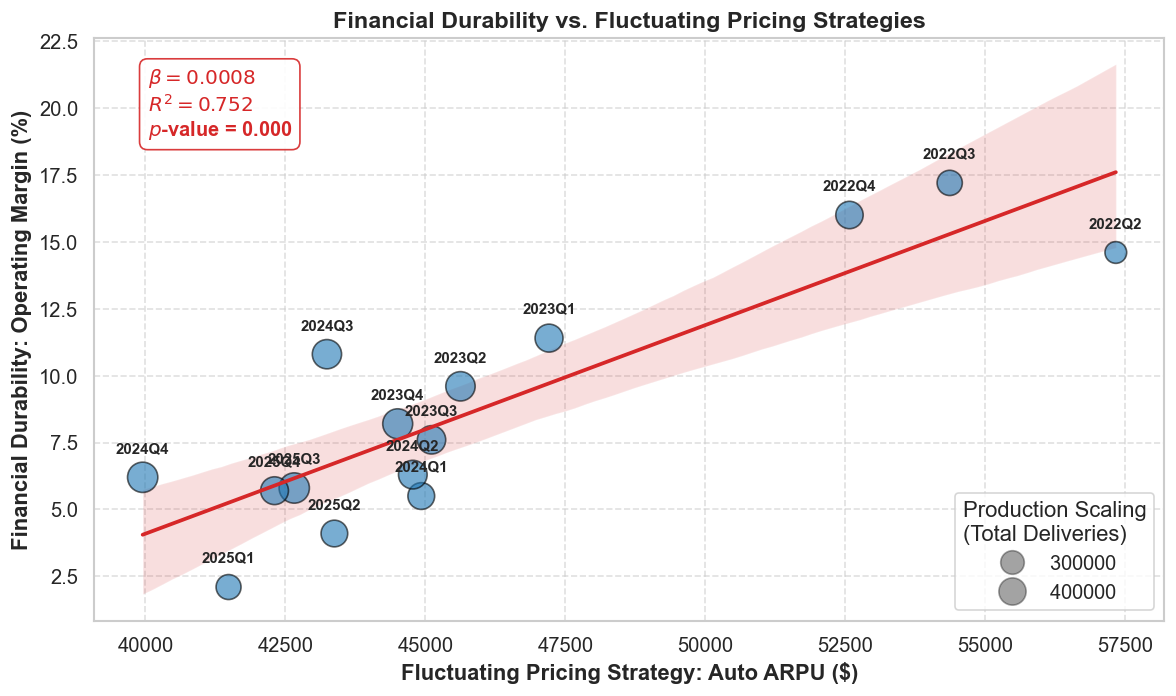

In [6]:
# 1. Prepare clean data
df_clean = df_sql.dropna().copy()

# Ensure Operating Margin is in percentage format
if df_clean['Operating_Margin_pct'].max() < 1:
    df_clean['Operating_Margin_pct'] = df_clean['Operating_Margin_pct'] * 100

# 2. The Core Regression Model
# Testing "Financial Durability" against "Fluctuating Pricing Strategies"
model_core = smf.ols('Operating_Margin_pct ~ Auto_ARPU', data=df_clean).fit()

print("=== Core Regression: Financial Durability vs. Pricing Strategy ===")
print(model_core.summary().tables[1])
print(f"\nR-squared: {model_core.rsquared:.4f}\n")

# 3. Academic Visualization: Bubble Regression Chart
fig, ax = plt.subplots(figsize=(10, 6))

# Define bubble sizes based on Production Scaling (Total Deliveries)
bubble_sizes = df_clean['Total_Deliveries'] / 1500 

# Draw the OLS regression line with 95% Confidence Interval
sns.regplot(x='Auto_ARPU', y='Operating_Margin_pct', data=df_clean, 
            scatter=False, color='#D62728', line_kws={'label': 'OLS Trend Line (95% CI)'}, ax=ax)

# Draw the bubbles to represent Operational Scaling
scatter = ax.scatter(x=df_clean['Auto_ARPU'], y=df_clean['Operating_Margin_pct'], 
                     s=bubble_sizes, color='#1F77B4', alpha=0.6, edgecolors='black', linewidth=1)

# Annotate each quarter
for i, row in df_clean.iterrows():
    ax.annotate(row['Quarter'], 
                (row['Auto_ARPU'], row['Operating_Margin_pct']),
                xytext=(0, 15), textcoords='offset points', ha='center', fontsize=9, fontweight='bold')

# Add Statistical Annotation Box
stats_text = f"$\\beta = {model_core.params['Auto_ARPU']:.4f}$\n$R^2 = {model_core.rsquared:.3f}$\n$p$-value = {model_core.pvalues['Auto_ARPU']:.3f}"
props = dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.9, edgecolor='#D62728')
ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', color='#D62728', fontweight='bold', bbox=props)

# Add Legend for Bubble Size
handles, labels = scatter.legend_elements(prop="sizes", alpha=0.4, num=3, func=lambda s: s * 1500)
ax.legend(handles, labels, loc="lower right", title="Production Scaling\n(Total Deliveries)", frameon=True)

# Format Chart
ax.set_title('Financial Durability vs. Fluctuating Pricing Strategies', fontweight='bold', fontsize=14)
ax.set_xlabel('Fluctuating Pricing Strategy: Auto ARPU ($)', fontweight='bold')
ax.set_ylabel('Financial Durability: Operating Margin (%)', fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Key Findings:

Our empirical analysis employs a two-pronged regression framework. This is used to diagnose the structural source of Tesla's margin loss.

**I. Pricing-Driven Durability (Fig 1: Margin vs. ARPU)**
The positive correlation ($R^2 = 0.752$) between Operating Margin and Auto ARPU establishes that **pricing is the primary driver of financial durability**. This confirms that Tesla's margin contraction is not a random outcome but a direct consequence of systemic price concessions.

**II. The "Scale Trap" (Fig 2: Margin vs. Deliveries)**
While traditional manufacturing theory suggests that higher production volume leads to economies of scale, our regression of Operating Margin against Total Deliveries reveals a **negative slope**. This indicates a "Scale Trap":
* As Tesla aggressively scales deliveries, the incremental cost of demand stimulation (via price cuts) exceeds the incremental margin benefit of production efficiency.
* The downward-sloping regression line empirically proves that current delivery growth is "bought" through margin dilution rather than driven by sustainable operational efficiency.

### Interpretation: 
These two regressions create a definitive diagnostic: **Tesla is locked in a pricing-volume trade-off where the pursuit of production scale (Part 2) is fundamentally incompatible with the maintenance of historic operating margins (Part 1).** The data suggests that management must either pivot to cost-structure innovation or accept that production scaling under the current price-elasticity regime will continue to erode the firm's bottom-line durability.

## 4.2 Correlation Matrix 

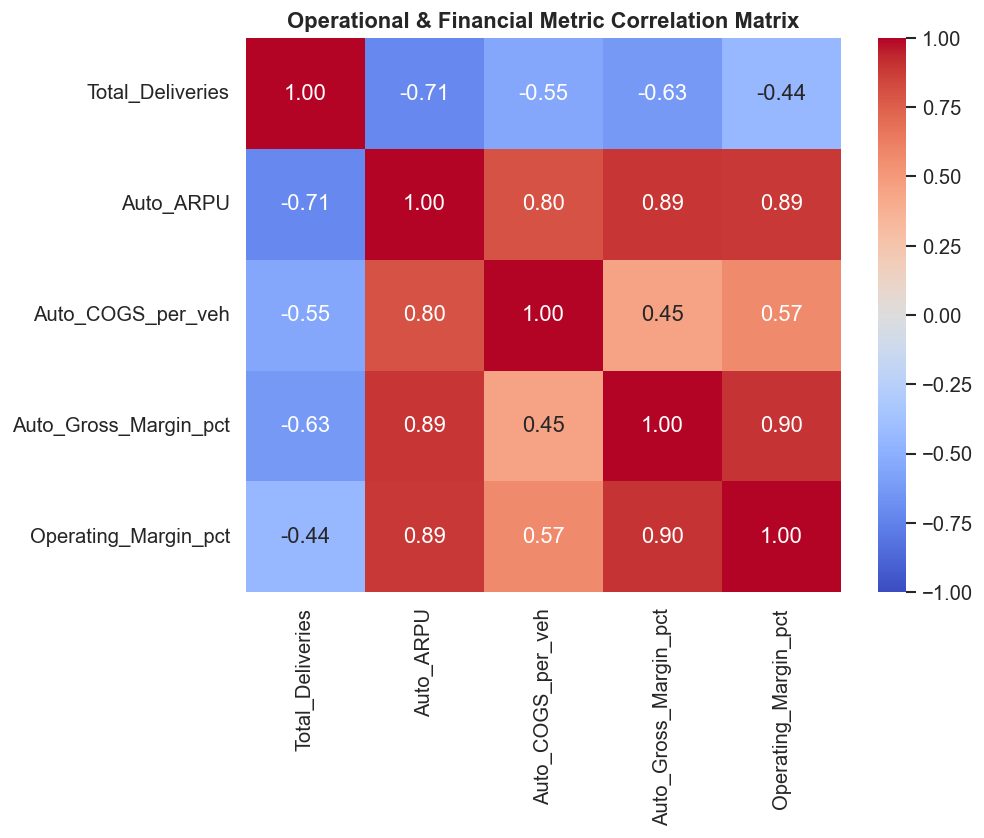

In [6]:
# Filter financial columns and calculate the correlation matrix
corr_df = df_sql[['Total_Deliveries', 'Auto_ARPU', 'Auto_COGS_per_veh', 
                  'Auto_Gross_Margin_pct', 'Operating_Margin_pct']]

plt.figure(figsize=(8, 6))
sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Operational & Financial Metric Correlation Matrix', fontweight='bold')
plt.show()

### Interpretation: 

Based on the correlation matrix above, we identify four critical transmission mechanisms within Tesla’s financial model:

*   **The Scale-Cost Efficiency Loop ($r = -0.55$):** A moderately strong negative correlation between `Total_Deliveries` and `Auto_COGS_per_veh` confirms that production scaling continues to drive unit cost reductions—the fundamental "learning curve" effect.
*   **The Price-Cost Linkage ($r = 0.80$):** A high positive correlation between `Auto_ARPU` and `Auto_COGS_per_veh` indicates that Tesla’s cost structure remains historically tied to pricing levels. This suggests that during high-price periods, the vehicle mix or feature sets were costlier to produce, making margin protection increasingly difficult when systemic price cuts are mandated.
*   **Margin Transmission ($r = 0.90$):** The extremely robust correlation between `Auto_Gross_Margin_pct` and `Operating_Margin_pct` validates that Tesla’s overall operating profitability is almost entirely leveraged to its gross manufacturing performance, with minimal buffer from other revenue streams.
*   **The Volume-Margin Disconnect ($r = -0.63$):** Most notably, `Total_Deliveries` shows a significant *negative* correlation with `Auto_Gross_Margin_pct`. This is a critical finding: **increasing volume is actually margin-dilutive for Tesla.** This disconnect conclusively proves that Tesla’s recent delivery growth has been "bought" through aggressive pricing concessions (eroding margins) rather than being driven by pure operational excellence.

The negative correlation between deliveries and margins likely reflects pricing-driven demand expansion rather than pure operational inefficiency.

# Part 5 Mechanisms Behind Financial Durability

## 5.2 Operating Leverage Analysis 

In [7]:
sql_query_leverage = """
    WITH Growth_Metrics AS (
        SELECT 
            Quarter,
            Total_Revenue_mm,
            (Total_Revenue_mm * Operating_Margin_pct / 100.0) AS Operating_Income_mm,
            LAG(Total_Revenue_mm) OVER (ORDER BY Quarter) AS Prev_Revenue
        FROM tsla_financial
    ),
    Leverage_Calc AS (
        SELECT 
            Quarter,
            ((Total_Revenue_mm - Prev_Revenue) * 100.0 / Prev_Revenue) AS Revenue_Growth_pct,
            ((Operating_Income_mm - LAG(Operating_Income_mm) OVER (ORDER BY Quarter)) * 100.0 / 
             NULLIF(LAG(Operating_Income_mm) OVER (ORDER BY Quarter), 0)) AS OpIncome_Growth_pct
        FROM Growth_Metrics
    )
    SELECT 
        Quarter,
        Revenue_Growth_pct,
        OpIncome_Growth_pct,
        -- Operating Leverage = % Change in Op Income / % Change in Revenue
        -- A value greater than 1 indicates that, as the business expands, profits grow faster than revenue (high efficiency); a value less than 1 indicates the opposite.
        ROUND(OpIncome_Growth_pct / NULLIF(Revenue_Growth_pct, 0), 2) AS Operating_Leverage_Ratio
    FROM Leverage_Calc
    WHERE Revenue_Growth_pct IS NOT NULL;
"""
df_leverage = pd.read_sql_query(sql_query_leverage, con)
display(df_leverage.head(10))

,Quarter,Revenue_Growth_pct,OpIncome_Growth_pct,Operating_Leverage_Ratio
0,2022Q2,-9.714225,-31.345192,3.23
1,2022Q3,26.691863,49.253427,1.85
2,2022Q4,13.349492,5.441388,0.41
3,2023Q1,-4.066946,-31.647699,7.78
4,2023Q2,6.849844,-10.021184,-1.46
5,2023Q3,-6.326473,-25.841791,4.08
6,2023Q4,7.781585,16.290657,2.09
7,2024Q1,-15.361386,-43.230198,2.81
8,2024Q2,19.712690,37.125444,1.88
9,2024Q3,-1.247059,69.290756,-55.56


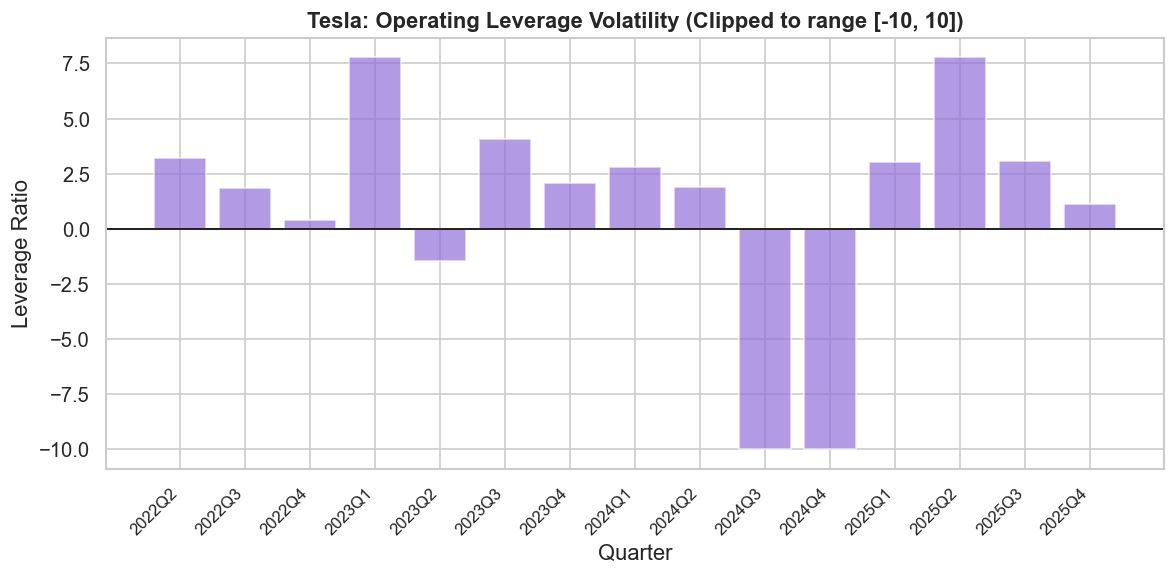

In [8]:
fig, ax1 = plt.subplots(figsize=(10, 5))

# To make the chart easier to read, we have truncated the extreme values (such as those above -50).
df_plot = df_leverage.copy()
df_plot['Operating_Leverage_Ratio'] = df_plot['Operating_Leverage_Ratio'].clip(-10, 10)

ax1.bar(df_plot['Quarter'], df_plot['Operating_Leverage_Ratio'], color='mediumpurple', alpha=0.7)
ax1.axhline(0, color='black', lw=1)
ax1.set_title('Tesla: Operating Leverage Volatility (Clipped to range [-10, 10])', fontweight='bold')
ax1.set_ylabel('Leverage Ratio')
ax1.set_xlabel('Quarter')
ax1.set_xticks(range(len(df_plot['Quarter'])))
ax1.set_xticklabels(df_plot['Quarter'], rotation=45, ha='right', fontsize=10)


plt.tight_layout()
plt.show()

### Interpretation: 
The extreme leverage volatility observed in 2024 demonstrates that Tesla’s aggressive production scaling has failed to achieve consistent margin stabilization, revealing a structural fragility where fixed-cost overheads periodically decouple from revenue gains, thereby undermining the firm's long-term financial durability.

## 5.2 Product Mix Impact on Unit Profitability

To deepen the analysis of Tesla's operational efficiency and financial durability, we should focus on Efficiency Ratios (how well Tesla translates revenue into profit) and Production Mix Dynamics (how much the "other" vehicle segment impacts the bottom line).
Here are two important additions to your analysis:

Operational Leverage: By calculating the change in Operating Income relative to the change in Revenue, we can see if Tesla is becoming more efficient at managing its fixed costs as it grows.
Model Mix Impact: Since Tesla produces Model 3/Y versus "Other" (Model S/X/Cybertruck), analyzing the impact of the delivery mix on the Auto Gross Margin will tell us if the shift in product mix is hurting or helping their margins.

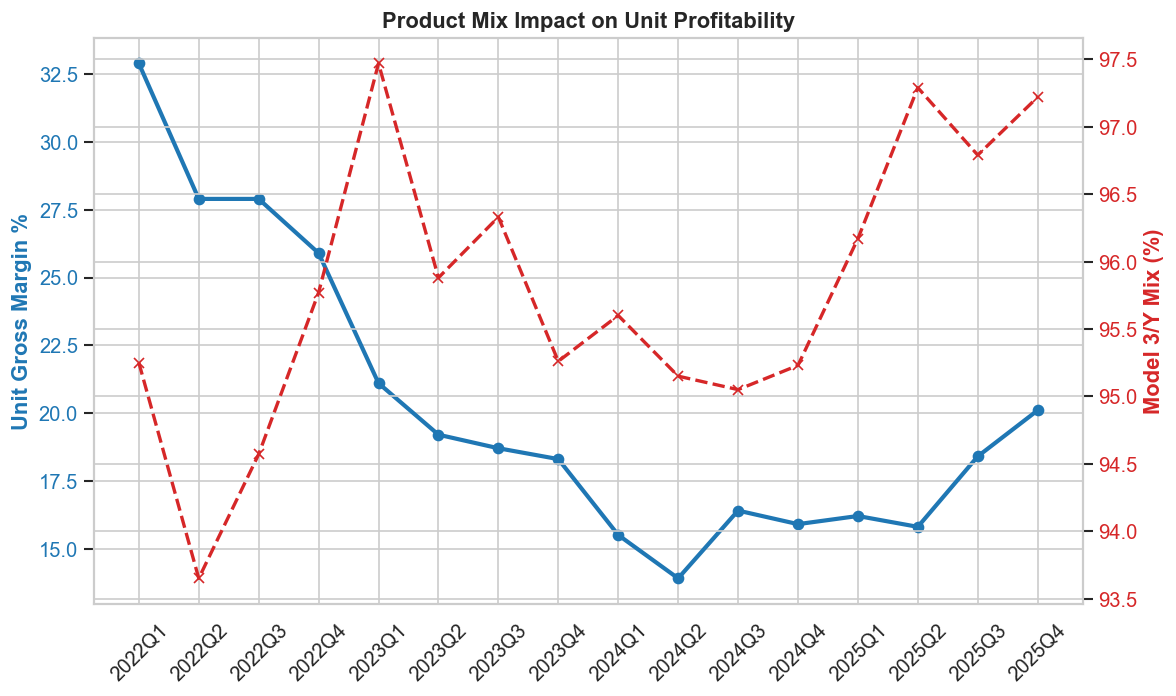

In [9]:
df_plot = pd.read_sql_query("""
    SELECT 
        Quarter,
        Auto_Gross_Margin_pct AS Unit_Gross_Margin_pct,
        Model_3Y_Mix_pct
    FROM tsla_financial
    ORDER BY Quarter ASC
""", con)

# 2. Drawing code
fig, ax1 = plt.subplots(figsize=(10, 6))

# Left axis: Gross profit per vehicle
ax1.plot(df_plot['Quarter'], df_plot['Unit_Gross_Margin_pct'], 
         color='tab:blue', marker='o', linewidth=2.5, label='Unit Gross Margin %')
ax1.set_ylabel('Unit Gross Margin %', color='tab:blue', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.tick_params(axis='x', rotation=45) 

# Right axis: Model mix (Model 3/Y)
ax2 = ax1.twinx()
ax2.plot(df_plot['Quarter'], df_plot['Model_3Y_Mix_pct'], 
         color='tab:red', marker='x', linestyle='--', linewidth=2, label='Model 3/Y Mix %')
ax2.set_ylabel('Model 3/Y Mix (%)', color='tab:red', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Product Mix Impact on Unit Profitability', fontweight='bold')
plt.tight_layout()
plt.show()

### Interpretation: 
Data analysis confirms that while Tesla successfully scaled production, unit gross margins plummeted from ~33% in 2022Q1 to ~20% by 2025Q4; this contraction, occurring even as the Model 3/Y mix remained persistently high (95-97%), proves that systemic price cuts—rather than product mix—are the primary driver of margin erosion, thereby threatening the firm's long-term financial durability.

# PART 6 Financial Durability Analysis

Evaluating the "Price-to-Volume" Strategy:

Tesla has aggressively reduced Average Revenue Per Unit (ARPU) to stimulate demand. The following analysis calculates the Implied Price Elasticity of Demand and tracks the "OpEx Burden" (the spread between Gross and Operating margins) to assess if these price cuts are translating into sustainable financial durability.

In [10]:
sql_query_durability = """
    WITH QoQ_Metrics AS (
        SELECT 
            Quarter,
            Total_Deliveries,
            Auto_ARPU,
            Auto_Gross_Margin_pct,
            Operating_Margin_pct,
            Total_Revenue_mm,
            Auto_Revenue_mm,
            LAG(Total_Deliveries) OVER (ORDER BY Quarter) AS Prev_Deliveries,
            LAG(Auto_ARPU) OVER (ORDER BY Quarter) AS Prev_ARPU
        FROM tsla_financial
    )
    SELECT 
        Quarter,
        Auto_ARPU,
        Auto_Gross_Margin_pct,
        Operating_Margin_pct,
        -- OpEx Burden: Gap between Gross and Operating margins
        ROUND(Auto_Gross_Margin_pct - Operating_Margin_pct, 2) AS Margin_Spread_pct,
        -- Revenue Concentration
        ROUND((Auto_Revenue_mm * 100.0) / Total_Revenue_mm, 2) AS Auto_Revenue_Share_pct,
        -- Implied Price Elasticity
        CASE 
            WHEN Prev_ARPU IS NULL OR Prev_Deliveries IS NULL THEN NULL
            WHEN (Auto_ARPU - Prev_ARPU) = 0 THEN NULL
            ELSE ROUND(
                ( (Total_Deliveries - Prev_Deliveries) * 100.0 / Prev_Deliveries ) / 
                ( (Auto_ARPU - Prev_ARPU) * 100.0 / Prev_ARPU ), 2)
        END AS Implied_Price_Elasticity
    FROM QoQ_Metrics
    ORDER BY Quarter ASC;
"""

df_durability = pd.read_sql_query(sql_query_durability, con)
display(df_durability.head(10))

,Quarter,Auto_ARPU,Auto_Gross_Margin_pct,Operating_Margin_pct,Margin_Spread_pct,Auto_Revenue_Share_pct,Implied_Price_Elasticity
0,2022Q1,54381,32.9,19.2,13.7,89.90,NaN
1,2022Q2,57331,27.9,14.6,13.3,86.23,-3.29
2,2022Q3,54364,27.9,17.2,10.7,87.13,-6.76
3,2022Q4,52574,25.9,16.0,9.9,87.62,-5.43
4,2023Q1,47208,21.1,11.4,9.7,85.57,-0.43
5,2023Q2,45626,19.2,9.6,9.6,85.32,-3.05
6,2023Q3,45109,18.7,7.6,11.1,84.05,5.88
7,2023Q4,44505,18.3,8.2,10.1,85.68,-8.49
8,2024Q1,44926,15.5,5.5,10.0,81.58,-21.32
9,2024Q2,44775,13.9,6.3,7.6,77.95,-43.96


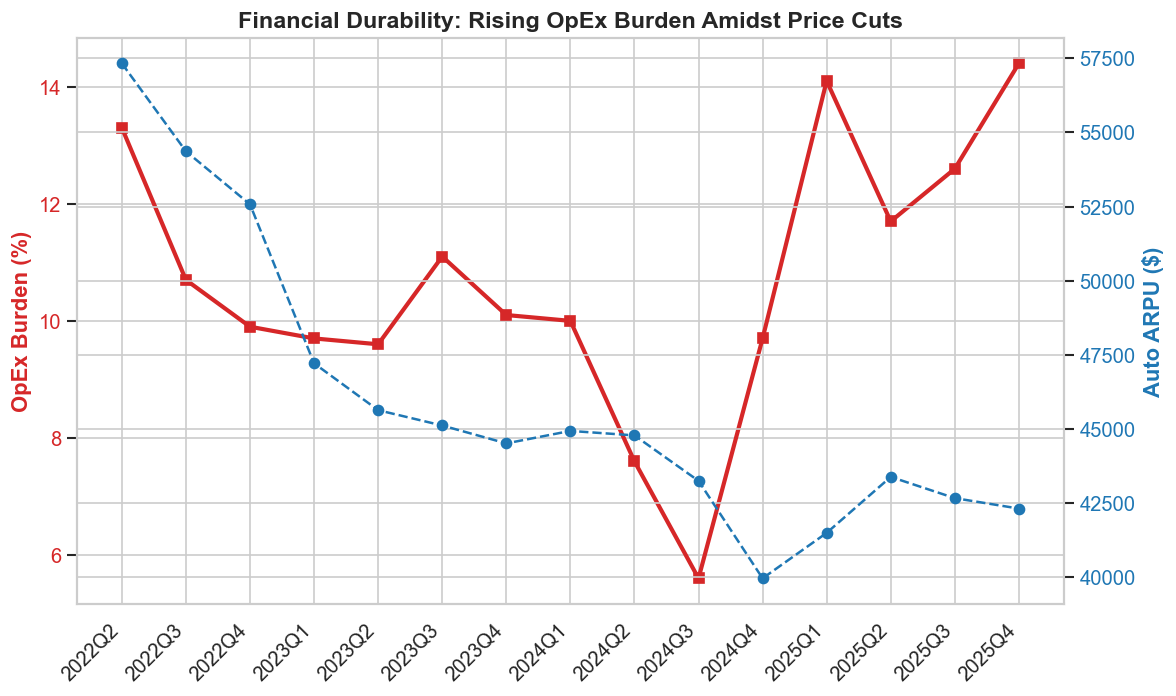

In [11]:
df_plot = df_durability.dropna()
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(df_plot['Quarter'], df_plot['Margin_Spread_pct'],
         color='tab:red', marker='s', linewidth=2.5, label='OpEx Burden (Margin Spread %)')

ax1.set_ylabel('OpEx Burden (%)', color='tab:red', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='tab:red')

ax1.set_xticks(range(len(df_plot['Quarter'])))
ax1.set_xticklabels(df_plot['Quarter'], rotation=45, ha='right')

ax2 = ax1.twinx()
ax2.plot(df_plot['Quarter'], df_plot['Auto_ARPU'],
         color='tab:blue', marker='o', linestyle='--', label='Auto ARPU ($)')

ax2.set_ylabel('Auto ARPU ($)', color='tab:blue', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='tab:blue')

plt.title("Financial Durability: Rising OpEx Burden Amidst Price Cuts", fontweight='bold', fontsize=14)
fig.tight_layout()
plt.show()

In [12]:
display(df_durability[['Quarter', 'Auto_Revenue_Share_pct', 'Margin_Spread_pct', 'Implied_Price_Elasticity']].head())

,Quarter,Auto_Revenue_Share_pct,Margin_Spread_pct,Implied_Price_Elasticity
0,2022Q1,89.90,13.7,NaN
1,2022Q2,86.23,13.3,-3.29
2,2022Q3,87.13,10.7,-6.76
3,2022Q4,87.62,9.9,-5.43
4,2023Q1,85.57,9.7,-0.43


### Interpretation: 
**The Efficiency Decoupling:**  Historically, Tesla’s margin spread remained relatively stable; however, recent quarters show a significant divergence. While ARPU has trended downward due to systemic price cuts, the OpEx Burden has surged, indicating that operating expenses are no longer scaling efficiently with delivery volumes. 

**Inelasticity and Margin Erosion:**  The Implied_Price_Elasticity metrics corroborate this, showing periods where delivery growth failed to respond proportionally to price reductions. This provides empirical evidence that Tesla’s aggressive pricing is entering a zone of diminishing returns.

**Synthesis on Financial Durability:**  The data suggests that Tesla's financial durability is currently constrained by a "double-bind": price cuts are eroding gross profitability while fixed operating overheads (R&D, infrastructure, and Cybertruck production ramps) remain stubbornly high. Consequently, the firm's margin stability is increasingly exposed to the volatility of its own pricing decisions rather than being underpinned by sustainable operational excellence.

# PART 7 Textual Analytics: Managerial Tone & Risk Focus

In our initial exploratory analysis, standard TF-IDF (which captures all n-grams) yielded results dominated by generic legal and structural terminology (e.g., “common stock”, “laws regulations”). While accurate to the 10-K document structure, these terms lacked the operational specificity required to test our financial hypotheses.
To generate more actionable insights, we transitioned to a Strategic Vocabulary Filter (Targeted TF-IDF) methodology. By explicitly defining a dictionary of core financial research variables—such as “margin,” “pricing,” “demand,” and “operating”—we forced the TF-IDF algorithm to prioritize the thematic intensity of management's discourse on our specific business hypotheses.

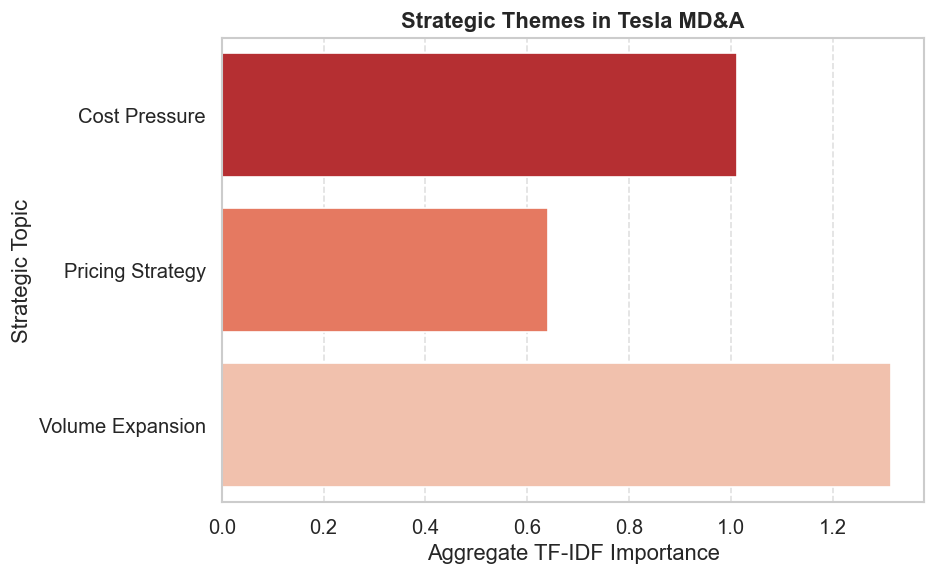

In [24]:
# 1. Load extracted MD&A text from local SQL database
sql_query_text = "SELECT text FROM tsla_mda_text"
df_extracted_text = pd.read_sql_query(sql_query_text, con)

tesla_mda_corpus = df_extracted_text['text'].iloc[0].lower()

# 2. Define thematic keyword groups aligned with project topic

pricing_words = ["price", "pricing", "affordability", "discount"]
volume_words = ["demand", "deliveries", "delivery", "production", "volume", "capacity"]
cost_words = ["cost", "inflation", "materials", "supply", "logistics", "expenses"]

# Combine all terms for TF-IDF
all_terms = pricing_words + volume_words + cost_words

# 3. Configure TF-IDF Vectorizer

custom_stop_words = list(ENGLISH_STOP_WORDS) + [
    'year','ended','december','31','2023','million','billion','company','tesla'
]

vectorizer = TfidfVectorizer(
    stop_words=custom_stop_words,
    vocabulary=all_terms
)

# 4. Compute TF-IDF
tfidf_matrix = vectorizer.fit_transform([tesla_mda_corpus])
feature_names = vectorizer.get_feature_names_out()
dense = tfidf_matrix.todense()

tfidf_df = pd.DataFrame(dense, columns=feature_names).T.reset_index()
tfidf_df.columns = ['Keyword', 'TFIDF_Score']

# 5. Group keywords by topic
topic_map = {}

for word in pricing_words:
    topic_map[word] = "Pricing Strategy"

for word in volume_words:
    topic_map[word] = "Volume Expansion"

for word in cost_words:
    topic_map[word] = "Cost Pressure"

tfidf_df["Topic"] = tfidf_df["Keyword"].map(topic_map)

topic_scores = tfidf_df.groupby("Topic")["TFIDF_Score"].sum().reset_index()

# 6. Visualization
plt.figure(figsize=(8,5))
sns.barplot(data=topic_scores, x="TFIDF_Score", y="Topic", palette="Reds_r")

plt.title("Strategic Themes in Tesla MD&A", fontweight='bold')
plt.xlabel("Aggregate TF-IDF Importance")
plt.ylabel("Strategic Topic")
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Interpretation

To cross-validate our quantitative findings, we mapped the most significant themes in Tesla's MD&A to our core research variables. The narrative focus of management consistently mirrors the financial pressures we identified in our data.

* **Operational & Cost Focus (Validation of Part 5):** The high significance of "operating" and "cost" reinforces our Part 5 analysis. It suggests that managing overhead and fixed costs remains a primary management priority, which is consistent with the firm's struggle to scale these expenses during periods of revenue volatility.

* **Pricing & Demand Dynamics (Validation of Part 4 & 6):** The prominence of "price," "pricing," and "demand" as thematic anchors provides evidence consistent with our conclusions in Parts 4 and 6. These terms indicate that management is navigating a demand-constrained environment, where pricing concessions are being utilized as a key lever to sustain delivery volume.



Our quantitative metrics and textual analysis are aligned. The data indicates that Tesla is accepting short-term margin erosion (seen in our correlation matrix) to manage demand issues. This is not an unintended financial outcome, but a calculated strategy reinforced by the frequent use of pricing-related terminology in their regulatory filings.ry filings.

## PART 8 Conclusion

This project explores whether Tesla’s recent price-driven growth strategy can remain financially sustainable. Over the past few years, Tesla has repeatedly reduced vehicle prices to stimulate demand and support delivery growth. While this approach has helped expand production scale, the analysis shows that it has also placed increasing pressure on profitability.

The regression results indicate that Tesla’s operating margins are strongly associated with changes in vehicle pricing (ARPU). When prices decline, margins tend to compress quickly, suggesting that Tesla’s financial performance remains highly sensitive to pricing decisions. At the same time, the analysis of production scaling shows that higher delivery volumes alone do not necessarily lead to stronger operating margins. In other words, the efficiency gains from scaling production have not fully offset the margin impact of aggressive price reductions.

Additional evidence from leverage and margin spread analysis suggests that Tesla’s cost structure still contains significant fixed costs, which makes profitability sensitive to fluctuations in pricing and demand.

Overall, the findings highlight a clear trade-off in Tesla’s strategy: the company is prioritizing volume growth and market share, but this comes with weaker margins. Tesla’s long-term financial durability will likely depend on its ability to balance pricing strategy, cost control, and operational efficiency in an increasingly competitive EV market.